# 05. How many organoids does a growth chart need? (subsampling)

Velasco protocol, `frac_NPC_IP`. From the 105 train samples, draw age-stratified subsets of n = 20, 40, 80 (10 draws each, seeds 2026..2035)
and n = 105 (all train, 1 fit). Refit the model on each subset and measure:

1. **Curve stability**: how far the median curve (p50, Paulsen 2022) lies from the curve fitted on all 105, averaged over days 20..192, in percentage points.
2. **Test MSLL** on the fixed 26 test samples (more negative is better).

Two models:
- `final`: the final model (logit + heteroskedastic + publication batch effect with per-publication noise).
- `no_batch`: the same without the batch effect. Fewer parameters, so it may cope better with small n.

Stratification: samples per age bin proportional to the train counts (bins 0-30/30-60/60-90/90-120/120+, at least 1 per bin).
Publications are *not* stratified, so a small draw can miss a publication; its test samples then get no z-score under `final`
and that draw's MSLL is over fewer test samples (column `n_test` below).

In [1]:
import sys, io, contextlib, tempfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..")
sys.path.insert(0, str(ROOT))
from src.growth_chart import fit_growth_chart, test_metrics, PUB_COLORS

FIG = ROOT / "figures"
OUT = ROOT / "results" / "subsampling"
OUT.mkdir(parents=True, exist_ok=True)
TMP = tempfile.mkdtemp()            # per-fit CSVs from fit_growth_chart go here, not into results/

df_all = pd.read_csv(ROOT / "data" / "hnoca_sample_composition.csv")
v = df_all[df_all["protocol"].str.contains("Velasco")].merge(pd.read_csv(ROOT / "data" / "split_velasco.csv"), on="sample")
v["age_bin"] = pd.cut(v["age"], [0, 30, 60, 90, 120, 200], labels=False)
train, test = v[v["split"] == "train"], v[v["split"] == "test"]
AGE_GRID = np.arange(20, 193)
print("train per age bin:", train["age_bin"].value_counts().sort_index().tolist(), "  test:", len(test))

train per age bin: [9, 33, 13, 27, 23]   test: 26


In [2]:
def stratified_subsample(n, seed):
    """n train samples, allocated to age bins in proportion to the train counts (at least 1 per bin)."""
    rng = np.random.default_rng(seed)
    counts = train["age_bin"].value_counts().sort_index()
    alloc = np.maximum(1, np.round(n * counts / counts.sum()).astype(int))
    while alloc.sum() > n:
        alloc[alloc.idxmax()] -= 1
    while alloc.sum() < n:
        alloc[(counts - alloc).idxmax()] += 1
    return pd.concat([g.loc[rng.choice(g.index, alloc[b], replace=False)] for b, g in train.groupby("age_bin")])

MODELS = {"final": dict(batch="publication", grid_batch="Paulsen, 2022"), "no_batch": dict(batch=None)}
DESIGN = [(20, range(10)), (40, range(10)), (80, range(10)), (105, [0])]

runs, curves = [], []
for model, kw in MODELS.items():
    for n, draws in DESIGN:
        for d in draws:
            sub = train if n == len(train) else stratified_subsample(n, 2026 + d)
            with contextlib.redirect_stdout(io.StringIO()):          # hide the per-fit NOTE / WARNING lines
                c, z = fit_growth_chart(pd.concat([sub, test]), "frac_NPC_IP", model_name=f"{model}_n{n}_d{d}",
                                        results_dir=TMP, age_grid=AGE_GRID, **kw)
            m = test_metrics(z)
            runs.append({"model": model, "n": n, "draw": d, "n_test": int(m["n_test"]), "MSLL": m["MSLL"],
                         "EV": m["EV"], "z_sd": m["z_sd"], "n_publications": sub["publication"].nunique(),
                         "min_per_publication": sub["publication"].value_counts().min()})
            curves.append(c.assign(model=model, n=n, draw=d))

runs = pd.DataFrame(runs)
curves = pd.concat(curves, ignore_index=True)

# Curve stability: mean |p50 - p50 of the all-105 fit of the same model| over the age grid, in percentage points.
ref = curves[curves["n"] == 105].set_index(["model", "age"])["p50"]
curves["p50_ref"] = ref.reindex(pd.MultiIndex.from_frame(curves[["model", "age"]])).values
dev = (curves.assign(absdev=lambda d: 100 * (d["p50"] - d["p50_ref"]).abs())
             .groupby(["model", "n", "draw"])["absdev"].mean().rename("p50_dev_pp"))
runs = runs.merge(dev.reset_index(), on=["model", "n", "draw"])

runs.round(4).to_csv(OUT / "runs.csv", index=False)
curves[["model", "n", "draw", "age", "p5", "p50", "p95"]].round(5).to_csv(OUT / "curves.csv", index=False)
print(len(runs), "fits")

62 fits


In [3]:
# Summary per model and n. Median and range over the 10 draws (MSLL can blow up in single draws, so use the median).
summary = runs.groupby(["model", "n"]).agg(
    p50_dev_pp_median=("p50_dev_pp", "median"), p50_dev_pp_max=("p50_dev_pp", "max"),
    MSLL_median=("MSLL", "median"), MSLL_worst=("MSLL", "max"),
    draws_MSLL_above_0=("MSLL", lambda s: int((s > 0).sum())),
    draws_missing_a_publication=("n_publications", lambda s: int((s < 4).sum())))
summary.round(2)

p50_dev_pp_median  p50_dev_pp_max  MSLL_median  MSLL_worst  \
model    n                                                                 
final    20                4.68           10.29        -0.35       16.89   
         40                2.15            4.24        -1.22       -0.49   
         80                0.73            1.06        -1.37       -1.26   
         105               0.00            0.00        -1.40       -1.40   
no_batch 20                3.19            4.69        -0.85        1.05   
         40                2.05            3.63        -1.06        0.31   
         80                0.72            1.74        -1.15       -1.09   
         105               0.00            0.00        -1.16       -1.16   

              draws_MSLL_above_0  draws_missing_a_publication  
model    n                                                     
final    20                    4                            1  
         40                    0                            0  
         80                    0                            0  
         105                   0                            0  
no_batch 20                    2                            1  
         40                    1                            0  
         80                    0                            0  
         105                   0                            0

## Figure 1: the 10 median curves at each n (final model)

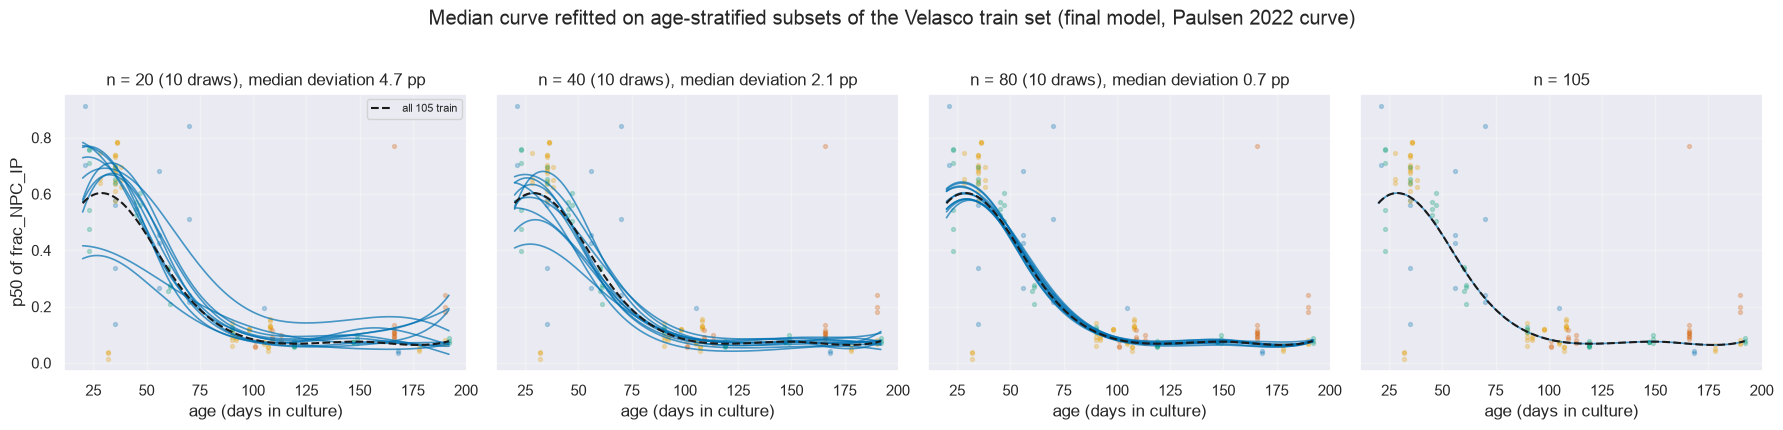

In [4]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.2), sharey=True)
for ax, (n, _) in zip(axes, DESIGN):
    for pub, g in v.groupby("publication"):
        ax.scatter(g["age"], g["frac_NPC_IP"], s=8, color=PUB_COLORS[pub], alpha=0.25, zorder=1)
    for d, g in curves[(curves["model"] == "final") & (curves["n"] == n)].groupby("draw"):
        ax.plot(g["age"], g["p50"], color="#0072B2", lw=1.2, alpha=0.7, zorder=2)
    r = curves[(curves["model"] == "final") & (curves["n"] == 105)]
    ax.plot(r["age"], r["p50"], color="k", lw=1.5, ls="--", zorder=3, label="all 105 train")
    med = summary.loc[("final", n), "p50_dev_pp_median"]
    ax.set_title(f"n = {n}" + ("" if n == 105 else f" (10 draws), median deviation {med:.1f} pp"))
    ax.set_xlabel("age (days in culture)")
    ax.grid(alpha=0.3)
axes[0].set_ylabel("p50 of frac_NPC_IP")
axes[0].legend(fontsize=8)
fig.suptitle("Median curve refitted on age-stratified subsets of the Velasco train set (final model, Paulsen 2022 curve)", y=1.02)
plt.tight_layout()
plt.savefig(FIG / "subsampling_p50_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Figure 2: the answer plot

Left: how far the median curve moves (percentage points of progenitor fraction). Right: test MSLL. Dots are single draws, lines the median.
MSLL is clipped at +2 for display; the number of draws above that is written next to the points.

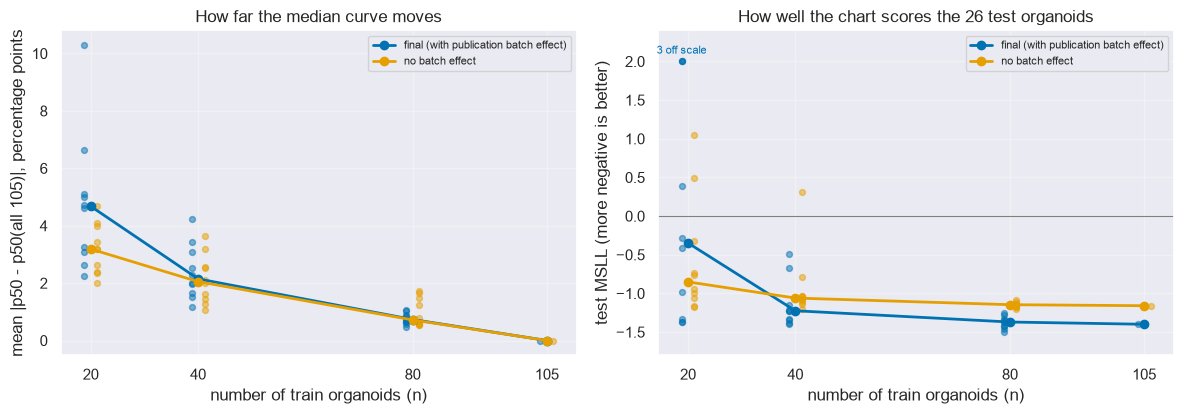

In [5]:
COLORS = {"final": "#0072B2", "no_batch": "#E69F00"}
LABELS = {"final": "final (with publication batch effect)", "no_batch": "no batch effect"}
CLIP = 2.0
fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
for model, dx in [("final", -1.2), ("no_batch", 1.2)]:
    r = runs[runs["model"] == model]
    s = summary.loc[model]
    for ax, col, agg in [(axes[0], "p50_dev_pp", "p50_dev_pp_median"), (axes[1], "MSLL", "MSLL_median")]:
        y = r[col].clip(upper=CLIP) if col == "MSLL" else r[col]
        ax.scatter(r["n"] + dx, y, s=18, color=COLORS[model], alpha=0.5)
        ax.plot(s.index, s[agg], color=COLORS[model], lw=2, marker="o", label=LABELS[model])
    for n, k in r[r["MSLL"] > CLIP].groupby("n").size().items():
        axes[1].text(n + dx, CLIP + 0.1, f"{k} off scale", color=COLORS[model], fontsize=8, ha="center")
axes[0].set_ylabel("mean |p50 - p50(all 105)|, percentage points")
axes[0].set_title("How far the median curve moves")
axes[1].set_ylabel("test MSLL (more negative is better)")
axes[1].set_title("How well the chart scores the 26 test organoids")
axes[1].set_ylim(-1.8, CLIP + 0.4)
axes[1].axhline(0, color="0.5", lw=0.8)
for ax in axes:
    ax.set_xlabel("number of train organoids (n)")
    ax.set_xticks([20, 40, 80, 105])
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(FIG / "subsampling_summary.png", dpi=150)
plt.show()